In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [34]:
data = pd.read_csv("ultimate_student_productivity_dataset_5000.csv")
data['pass'] = np.where(data['exam_score'] >= 24, 1, 0)
X = data.select_dtypes(include=np.number)
X = X.drop(columns=['exam_score','student_id','pass'])
y = data['pass']
print(y.value_counts())

pass
0    3336
1    1664
Name: count, dtype: int64


In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X_scaled)

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X_pca,y,test_size = 0.2, random_state = 42)
model = LogisticRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print("Explained Variance Ratio : ",pca.explained_variance_ratio_)
print("Accuracy after PCA : ",accuracy)
print("\nClassification Report :\n",classification_report(y_test,y_pred))

Explained Variance Ratio :  [0.17226563 0.11631706]
Accuracy after PCA :  0.862

Classification Report :
               precision    recall  f1-score   support

           0       0.88      0.92      0.90       658
           1       0.82      0.76      0.79       342

    accuracy                           0.86      1000
   macro avg       0.85      0.84      0.84      1000
weighted avg       0.86      0.86      0.86      1000



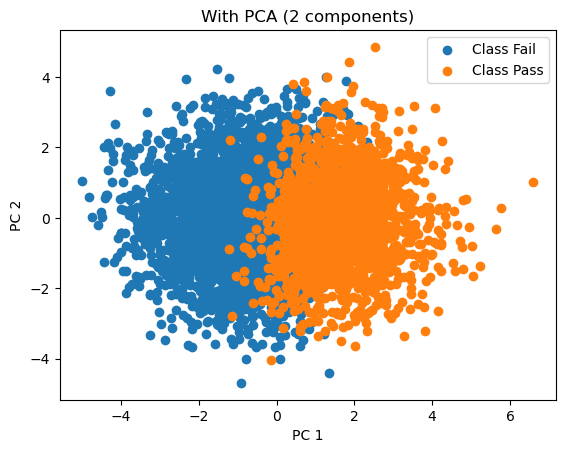

In [37]:
ps = ['Fail', 'Pass']
plt.figure()
for label in [0,1]:
    plt.scatter(
        X_pca[y == label, 0],
        X_pca[y == label, 1],
        label = f"Class {ps[label]}"
    )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.title("With PCA (2 components)")
plt.legend()
plt.show()